In [1]:
%load_ext autoreload
%autoreload 2
from helpers import *
from SINDyModel import *

In [2]:
def generate_noise_level_vs_dt_matrix(rhs, x0, t_span, noise_levels, dts, threshold, poly_order, generate_prediction=True):
    data = []

    for dt in dts:
        print(f"dt: {dt}")

        for noise_level in tqdm(noise_levels):
            data_entry = {}
            data_entry["dt"] = dt
            data_entry["noise_level"] = noise_level

            # generate evaluation time points
            t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
            data_entry["t_eval"] = t_eval

            # generate training data
            x_train = generate_training_data(rhs, x0, t_eval)
            data_entry["x_train"] = x_train
            
            # generate noisy data
            x_train_noisy = add_noise_to_data(x_train, noise_level)

            # generate the derivative of the noisy data
            x_dot_approx = dxdt(x_train_noisy, t_eval, kind="finite_difference", k=1)

            # create and fit a SINDy model
            model = SINDyModel(n_state_vars=len(x0), threshold=threshold, poly_order=poly_order)
            model.fit(x_train_noisy, x_dot_approx)
            data_entry["model"] = model

            # generate the model prediction if needed
            if generate_prediction is True:
                x_pred = generate_model_prediction(model, x0, t_eval)
                data_entry["x_pred"] = x_pred
            
            # store the data entry
            data.append(data_entry)
        
    return data


lotka_volterra_rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)

# noise_levels = [0, 0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 1]
# dts = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]
noise_levels = np.logspace(-4, 0, 10).tolist()
dts = np.logspace(-2, 0, 10).tolist()

data = generate_noise_level_vs_dt_matrix(
    rhs=lotka_volterra_rhs,
    x0=(10, 5),
    t_span=(0, 50),
    noise_levels=noise_levels,
    dts=dts,
    threshold=0.02,
    poly_order=5,
    generate_prediction=True
)


dt: 0.01


 60%|██████    | 6/10 [00:06<00:04,  1.01s/it]c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\SINDyModel.py:9: RuntimeWarning: overflow encountered in power
  return lambda x: np.prod(np.power(x, power_tuple), axis=1)
c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\SINDyModel.py:145: RuntimeWarning: invalid value encountered in matmul
  x_dot = Theta @ self.Xi
c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\scipy\integrate\_ivp\lsoda.py:161: UserWarning: lsoda: Excess accuracy requested (tolerances too small).
  solver._y, solver.t = integrator.run(
100%|██████████| 10/10 [00:15<00:00,  1.59s/it]


dt: 0.016681005372000592


100%|██████████| 10/10 [00:10<00:00,  1.02s/it]


dt: 0.027825594022071243


...

100%|██████████| 10/10 [00:06<00:00,  1.64it/s]


dt: 0.5994842503189409


100%|██████████| 10/10 [00:09<00:00,  1.10it/s]


dt: 1.0


 20%|██        | 2/10 [00:02<00:10,  1.28s/it]c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\scipy\integrate\_ivp\lsoda.py:161: UserWarning: lsoda: Repeated convergence failures (perhaps bad Jacobian or tolerances).
  solver._y, solver.t = integrator.run(
100%|██████████| 10/10 [00:15<00:00,  1.57s/it]


In [3]:
# make a matrix of the relative trajectory errors

rte_mtx = np.zeros((len(noise_levels), len(dts)))

for data_entry in data:    
    x_train = data_entry["x_train"]
    x_pred = data_entry["x_pred"]

    # calculate the relative trajectory error
    # if the model prediction is "None", set the rte to np.nan
    if x_pred is None:
        rte = np.nan
    else:
        rte = relative_trajectory_error(x_train, x_pred)
    
    # if the rte is greater than 5, set it to np.nan
    # this is meant to remove any models that are clearly not working
    if rte > 5:
        rte = np.nan
    
    dt_idx = dts.index(data_entry["dt"])
    noise_level_idx = noise_levels.index(data_entry["noise_level"])
    rte_mtx[noise_level_idx, dt_idx] = rte

rte_mtx

array([[3.04933458e-04, 2.32660142e-03, 1.74128717e-02, 1.21145081e-01,
        6.63860091e-01,            nan, 7.23904673e-01,            nan,
                   nan, 9.03384321e-01],
       [3.12614972e-04,            nan, 1.75076112e-02, 1.21562740e-01,
        6.63464972e-01, 6.05885018e-01, 7.24068171e-01, 7.06961160e-01,
        9.98596786e-01,            nan],
       [3.62813888e-04, 2.76900106e-03, 1.78278894e-02, 7.99036970e-01,
        6.62449474e-01,            nan, 7.24602199e-01, 7.06863138e-01,
                   nan,            nan],
       [5.22297838e-04, 3.82121168e-03, 1.87090000e-02, 7.83064647e-01,
        6.60182596e-01,            nan,            nan, 6.72268698e-01,
                   nan,            nan],
       [1.34668434e-03,            nan, 2.22516298e-02, 1.40732982e-01,
        6.57405683e-01,            nan, 1.00681618e+00, 7.05866433e-01,
        8.49035099e-01,            nan],
       [1.06115147e-02, 4.13753574e-02,            nan, 2.04817596e-01,
   

In [4]:
# make a matrix of the relative coefficient errors

# (very janky) set up the true coefficients
true_coeffs = np.zeros((21, 2))
true_coeffs[1, 0] = 1
true_coeffs[2, 0] = -0.1
true_coeffs[2, 1] = 0.75
true_coeffs[16, 1] = -1.5

rce_mtx = np.zeros((len(noise_levels), len(dts)))

for data_entry in data:    
    model = data_entry["model"]

    rce = relative_coefficient_error(model.Xi, true_coeffs)

    dt_idx = dts.index(data_entry["dt"])
    noise_level_idx = noise_levels.index(data_entry["noise_level"])
    rce_mtx[noise_level_idx, dt_idx] = rce

rce_mtx

array([[1.03108782e-07, 8.41001484e-07, 6.40400619e-06, 4.92382464e-05,
        3.53717492e-01, 1.07588535e-01, 9.49948041e-01, 9.67583563e-01,
        8.98170370e-01, 1.00152107e+00],
       [9.81598407e-08, 4.17101419e-01, 6.45559697e-06, 4.88683822e-05,
        3.54340574e-01, 8.06221348e-01, 9.50024771e-01, 1.00016193e+00,
        9.35955956e-01, 9.65836380e-01],
       [8.79395926e-08, 9.74190375e-07, 6.60590754e-06, 4.96866174e-04,
        3.56004960e-01, 7.90193539e-01, 9.50235078e-01, 1.00017030e+00,
        8.03718921e-01, 9.65967724e-01],
       [8.60369889e-08, 1.30351094e-06, 7.07849193e-06, 4.08550885e-04,
        3.60101600e-01, 7.91322252e-01, 1.10549174e-01, 7.19453049e-01,
        7.31575822e-01, 9.49294259e-01],
       [2.71450096e-07, 4.18292297e-01, 8.86437381e-06, 4.02870265e-05,
        3.67413589e-01, 1.35868355e-01, 9.95618939e-01, 1.00024073e+00,
        6.13838445e-01, 8.53526080e-01],
       [2.30089293e-06, 1.35935683e-05, 3.01195952e-03, 3.88681800e-05,
   

[Text(0.5, 65.44999999999999, 'dt'),
 Text(80.45, 0.5, 'noise level'),
 Text(0.5, 1.0, 'Relative Trajectory Error')]

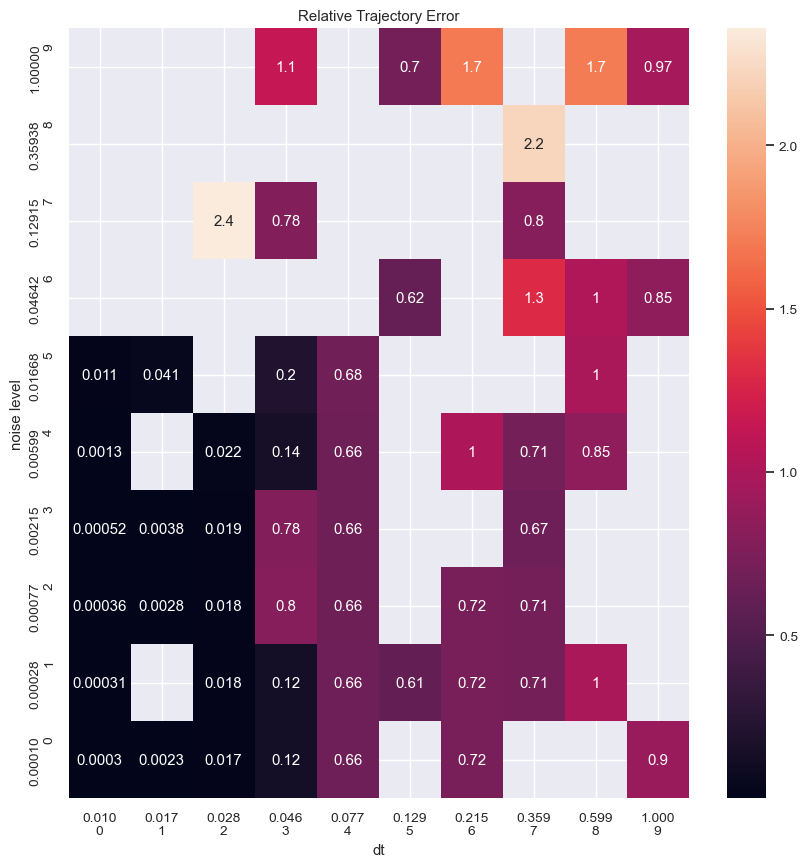

In [19]:
import seaborn as sns

fig = plt.figure(figsize=(10, 10))

sns.set_theme(font_scale=0.9)
ax = sns.heatmap(rte_mtx[::-1, :], annot=True,
                 xticklabels=[f"{dt:.3f}\n{i}" for i, dt in enumerate(dts)],
                 yticklabels=[f"{noise_level:.5f}\n{i}" for i, noise_level in list(enumerate(noise_levels))[::-1]])

ax.set(xlabel='dt', ylabel='noise level', title='Relative Trajectory Error')

[Text(0.5, 65.44999999999999, 'dt'),
 Text(80.45, 0.5, 'noise level'),
 Text(0.5, 1.0, 'Relative Coefficient Error')]

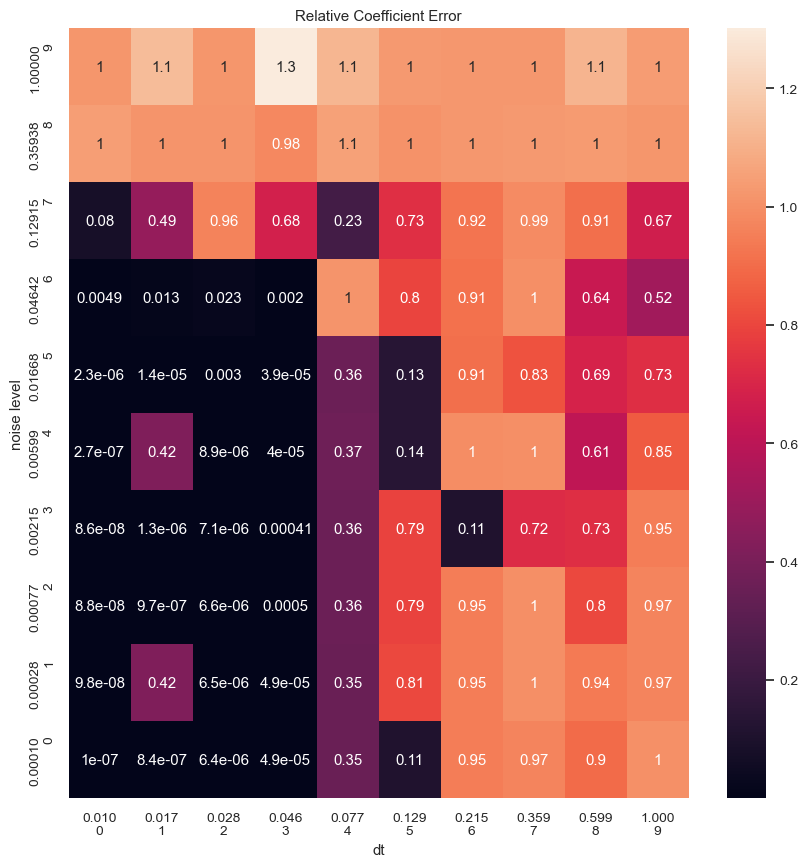

In [20]:
import seaborn as sns

fig = plt.figure(figsize=(10, 10))

sns.set_theme(font_scale=0.9)
ax = sns.heatmap(rce_mtx[::-1, :], annot=True,
                 xticklabels=[f"{dt:.3f}\n{i}" for i, dt in enumerate(dts)],
                 yticklabels=[f"{noise_level:.5f}\n{i}" for i, noise_level in list(enumerate(noise_levels))[::-1]])

ax.set(xlabel='dt', ylabel='noise level', title="Relative Coefficient Error")

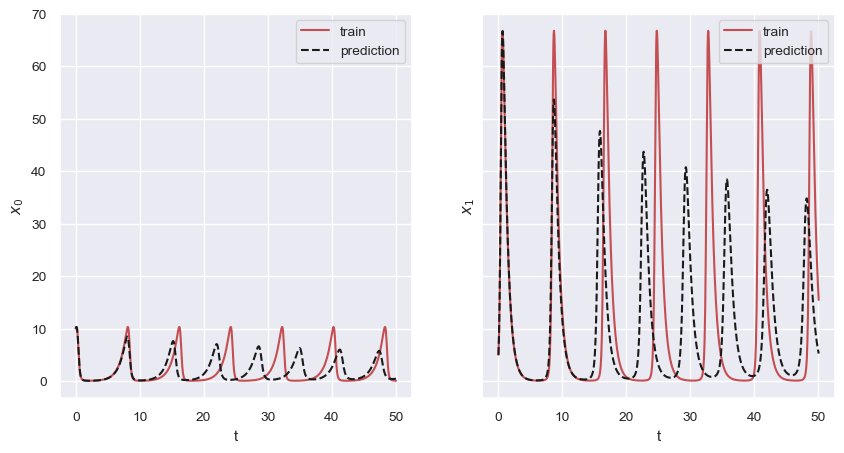

In [24]:
# set the indices of the data entry you'd like to explore
dt_idx = 3
noise_level_idx = 2

# find the data entry with the specified dt and noise level
data_entry = None
for de in data:
    if de["dt"] == dts[dt_idx] and de["noise_level"] == noise_levels[noise_level_idx]:
        data_entry = de

# extract the relevant data from the data entry
t_eval = data_entry['t_eval']
x_train = data_entry['x_train']
x_pred = data_entry['x_pred']

n_state_vars = x_train.shape[0]

# plot the training data and model prediction
fig, axs = plt.subplots(1, n_state_vars, figsize=(10, 5), sharex='col', sharey='row')

for sv in range(n_state_vars):
    # plot the col'th training state variable
    axs[sv].plot(t_eval, x_train[sv], "r", label="train")

    # plot the col'th state variable model prediction
    axs[sv].plot(t_eval, x_pred[sv], "k--", label="prediction")

    # set labels
    axs[sv].set_xlabel("t")
    axs[sv].set_ylabel(f"$x_{sv}$")
    axs[sv].legend()